# Análise de Fairness no Sistema COMPAS
**Autor:** Gilson Machado Monteiro  
**Data:** 05/02/2025  
**Fonte:** [ProPublica COMPAS Dataset](https://www.propublica.org/datastore/dataset/compas-recidivism-risk-score-data-and-analysis)  
**Referência:** Angwin et al. (2016) — Machine Bias, ProPublica


## Contexto

O sistema **COMPAS** (Correctional Offender Management Profiling for Alternative Sanctions) é um algoritmo usado em tribunais americanos para prever a probabilidade de reincidência criminal. Em 2016, a ProPublica publicou uma investigação mostrando que o sistema apresentava viés racial sistemático.

Este projeto reproduz e estende essa análise, aplicando testes estatísticos formais e métricas de fairness.


## 1. Definição do Problema

**Pergunta central:** O algoritmo COMPAS trata grupos raciais de forma desigual?

**Hipóteses:**

- **H₀:** Não há diferença significativa nas taxas de falsos positivos (FPR) entre negros e brancos.
- **H₁:** Há diferença significativa nas taxas de falsos positivos entre os grupos.

**Threshold adotado:** `decile_score > 5` = classificado como alto risco (padrão ProPublica).
Esse critério é mantido consistentemente em toda a análise.


In [11]:
# ── CÉLULA 0: setup ──────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/compas-fairness-analysis'

for pasta in ['notebooks', 'reports', 'src']:
    os.makedirs(f'{BASE}/{pasta}', exist_ok=True)

print("✓ Drive montado")
print("✓ Estrutura criada em:", BASE)

Mounted at /content/drive
✓ Drive montado
✓ Estrutura criada em: /content/drive/MyDrive/compas-fairness-analysis


## 2. Carregamento e Pré-processamento


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── Carregar dados ────────────────────────────────────────────────────────────
url = 'https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv'
df_raw = pd.read_csv(url)

print(f'Shape original     : {df_raw.shape}')
print(f'Colunas disponíveis: {df_raw.columns.tolist()}')


Shape original     : (7214, 53)
Colunas disponíveis: ['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_days_from_compas', 'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number', 'r_charge_degree', 'r_days_from_arrest', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid', 'is_violent_recid', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'decile_score.1', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_decile_score', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


In [2]:
# ── Filtrar colunas e grupos relevantes ───────────────────────────────────────
cols = ['race', 'decile_score', 'two_year_recid']
df = df_raw[cols].dropna()

# Threshold padrão ProPublica
THRESHOLD = 5  # decile_score > THRESHOLD = alto risco

# Separar grupos
black = df[df['race'] == 'African-American']
white = df[df['race'] == 'Caucasian']

print(f'Shape filtrado     : {df.shape}')
print(f'Distribuição racial:')
print(df['race'].value_counts().to_string())
print(f'\nGrupos para análise:')
print(f'  African-American : {len(black):,} observações')
print(f'  Caucasian        : {len(white):,} observações')
print(f'\nValores nulos restantes: {df.isnull().sum().sum()}')
print(f'Threshold adotado  : decile_score > {THRESHOLD} = alto risco')


Shape filtrado     : (7214, 3)
Distribuição racial:
race
African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18

Grupos para análise:
  African-American : 3,696 observações
  Caucasian        : 2,454 observações

Valores nulos restantes: 0
Threshold adotado  : decile_score > 5 = alto risco


## 3. Análise Exploratória


In [3]:
# ── Estatísticas descritivas por grupo ───────────────────────────────────────
resumo = df.groupby('race')['decile_score'].agg(['mean','median','std','min','max','count'])
resumo.columns = ['Média','Mediana','Std','Mín','Máx','N']
print('ESTATÍSTICAS DESCRITIVAS — decile_score')
print('─'*55)
print(resumo.loc[['African-American','Caucasian']].round(3).to_string())
print(f'\nDiferença de médias: {black["decile_score"].mean() - white["decile_score"].mean():.4f}')


ESTATÍSTICAS DESCRITIVAS — decile_score
───────────────────────────────────────────────────────
                  Média  Mediana    Std  Mín  Máx     N
race                                                   
African-American  5.369      5.0  2.831    1   10  3696
Caucasian         3.735      3.0  2.598    1   10  2454

Diferença de médias: 1.6337


/tmp/ipykernel_2422/3789517426.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='race', y='decile_score',


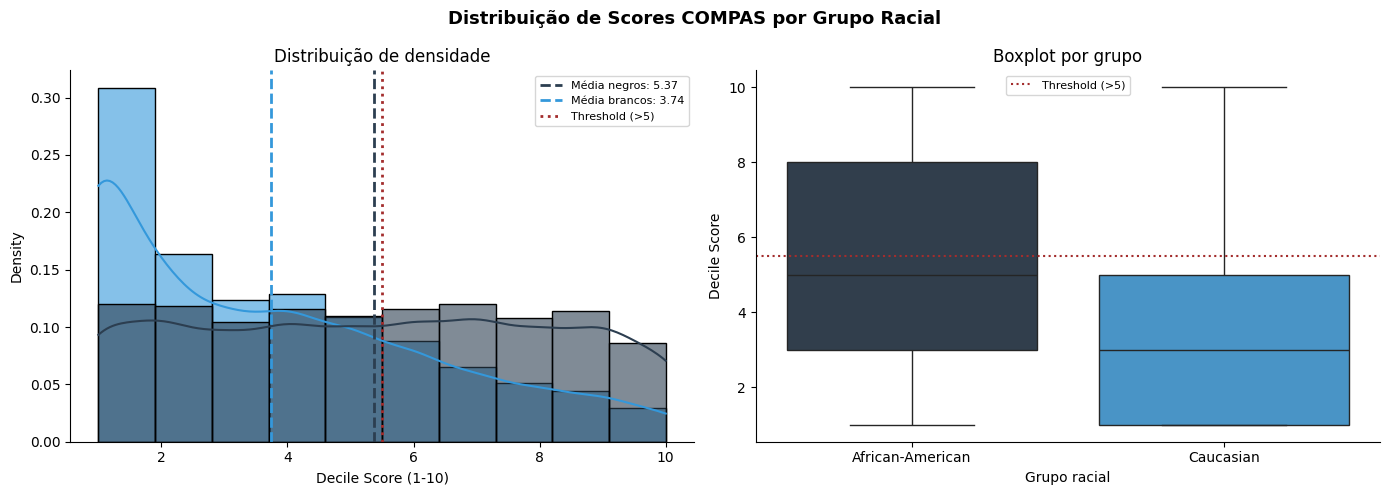

In [12]:
# ── Distribuição dos scores por grupo ────────────────────────────────────────
paleta = {'African-American': '#2c3e50', 'Caucasian': '#3498db'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição de Scores COMPAS por Grupo Racial', fontsize=13, fontweight='bold')

# Plot 1: histograma com KDE
sns.histplot(
    data=df[df['race'].isin(['African-American','Caucasian'])],
    x='decile_score', hue='race', bins=10, kde=True,
    stat='density', common_norm=False,
    palette=paleta, alpha=0.6,
    hue_order=['African-American','Caucasian'],
    ax=axes[0]
)
axes[0].axvline(black['decile_score'].mean(), color=paleta['African-American'],
                linestyle='--', lw=2, label=f'Média negros: {black["decile_score"].mean():.2f}')
axes[0].axvline(white['decile_score'].mean(), color=paleta['Caucasian'],
                linestyle='--', lw=2, label=f'Média brancos: {white["decile_score"].mean():.2f}')
axes[0].axvline(THRESHOLD + 0.5, color='#A32D2D', lw=2, linestyle=':',
                label=f'Threshold (>{THRESHOLD})')
axes[0].set_title('Distribuição de densidade')
axes[0].set_xlabel('Decile Score (1-10)')
axes[0].legend(fontsize=8)

# Plot 2: boxplot
df_plot = df[df['race'].isin(['African-American','Caucasian'])]
sns.boxplot(data=df_plot, x='race', y='decile_score',
            palette=paleta, ax=axes[1])
axes[1].set_title('Boxplot por grupo')
axes[1].set_xlabel('Grupo racial')
axes[1].set_ylabel('Decile Score')
axes[1].axhline(THRESHOLD + 0.5, color='#A32D2D', lw=1.5, linestyle=':',
                label=f'Threshold (>{THRESHOLD})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{BASE}/reports/distribuicao_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Verificação de Pressupostos e Teste de Hipóteses

Antes do teste t, verificamos dois pressupostos:
1. **Normalidade** — Shapiro-Wilk
2. **Homogeneidade de variâncias** — Levene


In [5]:
# ── Pressuposto 1: Normalidade (Shapiro-Wilk) ────────────────────────────────
# Com n grande, Shapiro-Wilk tende a rejeitar H0 mesmo com distribuições
# aproximadamente normais — interpretamos junto com o histograma
stat_b, p_norm_b = stats.shapiro(black['decile_score'].sample(500, random_state=42))
stat_w, p_norm_w = stats.shapiro(white['decile_score'].sample(min(500, len(white)), random_state=42))

print('NORMALIDADE — Shapiro-Wilk (amostra n=500)')
print(f'  African-American : W={stat_b:.4f}  p={p_norm_b:.4f}  {"✓ Normal" if p_norm_b > 0.05 else "✗ Não normal"}')
print(f'  Caucasian        : W={stat_w:.4f}  p={p_norm_w:.4f}  {"✓ Normal" if p_norm_w > 0.05 else "✗ Não normal"}')
print('  Nota: com n grande, violações de normalidade são esperadas.')
print('  O t-test é robusto a essas violações pelo Teorema Central do Limite.')

# ── Pressuposto 2: Homogeneidade de variâncias (Levene) ───────────────────────
stat_lev, p_lev = stats.levene(black['decile_score'], white['decile_score'])
print(f'\nHOMOGENEIDADE — Levene')
print(f'  F={stat_lev:.4f}  p={p_lev:.4f}  {"✓ Variâncias iguais" if p_lev > 0.05 else "✗ Variâncias diferentes — usar Welch"}')

equal_var = p_lev > 0.05
print(f'\nTeste selecionado: {"Student t-test" if equal_var else "Welch t-test"}')


NORMALIDADE — Shapiro-Wilk (amostra n=500)
  African-American : W=0.9376  p=0.0000  ✗ Não normal
  Caucasian        : W=0.8830  p=0.0000  ✗ Não normal
  Nota: com n grande, violações de normalidade são esperadas.
  O t-test é robusto a essas violações pelo Teorema Central do Limite.

HOMOGENEIDADE — Levene
  F=60.4663  p=0.0000  ✗ Variâncias diferentes — usar Welch

Teste selecionado: Welch t-test


In [6]:
# ── Welch t-test ─────────────────────────────────────────────────────────────
t_stat, p_value = ttest_ind(
    black['decile_score'], white['decile_score'], equal_var=equal_var
)

# Cohen's d
def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    s1, s2 = np.std(g1, ddof=1), np.std(g2, ddof=1)
    s_pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return (np.mean(g1) - np.mean(g2)) / s_pooled

d = cohen_d(black['decile_score'], white['decile_score'])
ef = 'pequeno' if abs(d) < 0.2 else 'médio' if abs(d) < 0.8 else 'grande'

print('TESTE DE HIPÓTESES — Comparação de Médias')
print('─'*50)
print(f'  Média negros   : {black["decile_score"].mean():.4f}')
print(f'  Média brancos  : {white["decile_score"].mean():.4f}')
print(f'  Diferença      : {black["decile_score"].mean() - white["decile_score"].mean():+.4f}')
print(f'  t-statistic    : {t_stat:.4f}')
print(f'  p-value        : {p_value:.2e}')
print(f'  Significativo  : {"✓ SIM — rejeita H0" if p_value < 0.05 else "✗ NÃO"}')
print(f"  Cohen's d      : {d:.4f} (efeito {ef})")


TESTE DE HIPÓTESES — Comparação de Médias
──────────────────────────────────────────────────
  Média negros   : 5.3688
  Média brancos  : 3.7351
  Diferença      : +1.6337
  t-statistic    : 23.2929
  p-value        : 1.39e-114
  Significativo  : ✓ SIM — rejeita H0
  Cohen's d      : 0.5961 (efeito médio)


## 5. Análise de Viés nas Decisões

Usando o threshold padrão `decile_score > 5` como critério de alto risco:


In [7]:
# ── Taxa de classificação como alto risco ─────────────────────────────────────
high_risk_black = (black['decile_score'] > THRESHOLD).mean()
high_risk_white = (white['decile_score'] > THRESHOLD).mean()

print(f'CLASSIFICAÇÃO COMO ALTO RISCO (threshold > {THRESHOLD})')
print('─'*50)
print(f'  African-American : {high_risk_black:.2%}')
print(f'  Caucasian        : {high_risk_white:.2%}')
print(f'  Razão            : {high_risk_black/high_risk_white:.2f}x mais provável para negros')

# ── Paridade Demográfica ──────────────────────────────────────────────────────
dem_parity = abs(high_risk_black - high_risk_white)
print(f'\nPARIDADE DEMOGRÁFICA')
print(f'  Diferença absoluta : {dem_parity:.4f} ({dem_parity:.2%})')
print(f'  Critério 80% rule  : razão = {min(high_risk_black,high_risk_white)/max(high_risk_black,high_risk_white):.2f}')
print(f'  {"✗ VIOLA" if min(high_risk_black,high_risk_white)/max(high_risk_black,high_risk_white) < 0.8 else "✓ SATISFAZ"} paridade demográfica (80% rule)')


CLASSIFICAÇÃO COMO ALTO RISCO (threshold > 5)
──────────────────────────────────────────────────
  African-American : 48.94%
  Caucasian        : 24.98%
  Razão            : 1.96x mais provável para negros

PARIDADE DEMOGRÁFICA
  Diferença absoluta : 0.2397 (23.97%)
  Critério 80% rule  : razão = 0.51
  ✗ VIOLA paridade demográfica (80% rule)


## 6. Teste de Hipóteses — Taxas de Falsos Positivos

FPR = proporção de não reincidentes classificados erroneamente como alto risco.


In [8]:
# ── FPR por grupo ─────────────────────────────────────────────────────────────
def calculate_fpr(df_group, threshold=THRESHOLD):
    fp = len(df_group[(df_group['decile_score'] > threshold) & (df_group['two_year_recid'] == 0)])
    tn = len(df_group[(df_group['decile_score'] <= threshold) & (df_group['two_year_recid'] == 0)])
    return fp / (fp + tn) if (fp + tn) > 0 else 0

fpr_b = calculate_fpr(black)
fpr_w = calculate_fpr(white)

print(f'TAXAS DE FALSOS POSITIVOS (FPR) — threshold > {THRESHOLD}')
print('─'*50)
print(f'  FPR negros  : {fpr_b:.4f} ({fpr_b:.2%})')
print(f'  FPR brancos : {fpr_w:.4f} ({fpr_w:.2%})')
print(f'  Razão FPR   : {fpr_b/fpr_w:.2f}x maior para negros')

# ── Qui-Quadrado ──────────────────────────────────────────────────────────────
n_b = len(black[black['two_year_recid'] == 0])
n_w = len(white[white['two_year_recid'] == 0])

contingency = np.array([
    [round(fpr_b * n_b), round((1 - fpr_b) * n_b)],
    [round(fpr_w * n_w), round((1 - fpr_w) * n_w)]
])

chi2, p_chi, dof, _ = chi2_contingency(contingency)
print(f'\nTESTE QUI-QUADRADO — FPR negros vs brancos')
print(f'  χ² = {chi2:.4f}  df = {dof}  p = {p_chi:.2e}')
print(f'  {"✓ Rejeita H0 — viés estatisticamente significativo" if p_chi < 0.05 else "✗ Não rejeita H0"}')


TAXAS DE FALSOS POSITIVOS (FPR) — threshold > 5
──────────────────────────────────────────────────
  FPR negros  : 0.3432 (34.32%)
  FPR brancos : 0.1472 (14.72%)
  Razão FPR   : 2.33x maior para negros

TESTE QUI-QUADRADO — FPR negros vs brancos
  χ² = 163.7631  df = 1  p = 1.70e-37
  ✓ Rejeita H0 — viés estatisticamente significativo


## 7. Métricas de Fairness — Equalized Odds

**Equalized Odds** exige que TPR e FPR sejam iguais entre grupos.
- **TPR (True Positive Rate):** proporção de reincidentes corretamente identificados
- **FPR (False Positive Rate):** proporção de não reincidentes erroneamente classificados como risco


In [9]:
# ── TPR e FPR por grupo ───────────────────────────────────────────────────────
def calculate_metrics(df_group, threshold=THRESHOLD):
    tp = len(df_group[(df_group['decile_score'] > threshold) & (df_group['two_year_recid'] == 1)])
    fp = len(df_group[(df_group['decile_score'] > threshold) & (df_group['two_year_recid'] == 0)])
    tn = len(df_group[(df_group['decile_score'] <= threshold) & (df_group['two_year_recid'] == 0)])
    fn = len(df_group[(df_group['decile_score'] <= threshold) & (df_group['two_year_recid'] == 1)])
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    return {'TPR': tpr, 'FPR': fpr, 'PPV': ppv,
            'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn}

m_b = calculate_metrics(black)
m_w = calculate_metrics(white)

print(f'MÉTRICAS DE FAIRNESS — threshold > {THRESHOLD}')
print('─'*55)
print(f'  {"Métrica":<8} {"Negros":>10} {"Brancos":>10} {"Diferença":>12}')
print('─'*55)
for k in ['TPR','FPR','PPV']:
    diff = m_b[k] - m_w[k]
    print(f'  {k:<8} {m_b[k]:>10.4f} {m_w[k]:>10.4f} {diff:>+12.4f}')
print('─'*55)
print(f'\nEQUALIZED ODDS:')
print(f'  TPR igual? {"✓" if abs(m_b["TPR"]-m_w["TPR"]) < 0.05 else "✗"} diferença = {abs(m_b["TPR"]-m_w["TPR"]):.4f}')
print(f'  FPR igual? {"✓" if abs(m_b["FPR"]-m_w["FPR"]) < 0.05 else "✗"} diferença = {abs(m_b["FPR"]-m_w["FPR"]):.4f}')
print(f'  Conclusão: {"✗ VIOLA Equalized Odds" if abs(m_b["TPR"]-m_w["TPR"]) >= 0.05 or abs(m_b["FPR"]-m_w["FPR"]) >= 0.05 else "✓ SATISFAZ Equalized Odds"}')


MÉTRICAS DE FAIRNESS — threshold > 5
───────────────────────────────────────────────────────
  Métrica      Negros    Brancos    Diferença
───────────────────────────────────────────────────────
  TPR          0.6276     0.4079      +0.2197
  FPR          0.3432     0.1472      +0.1960
  PPV          0.6595     0.6427      +0.0167
───────────────────────────────────────────────────────

EQUALIZED ODDS:
  TPR igual? ✗ diferença = 0.2197
  FPR igual? ✗ diferença = 0.1960
  Conclusão: ✗ VIOLA Equalized Odds


## 8. Visualização das Disparidades


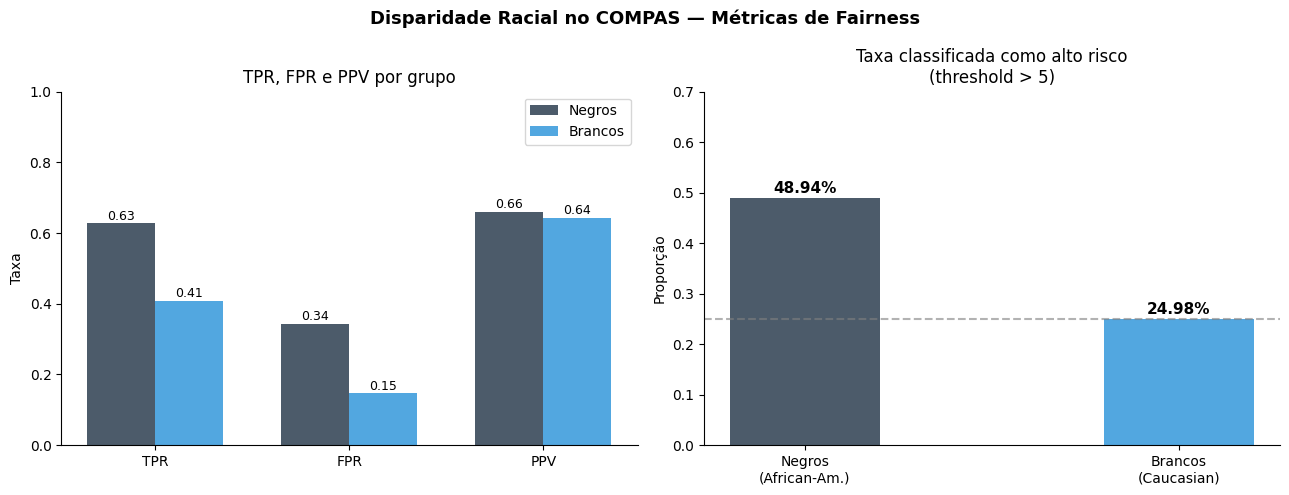

In [13]:
# ── Forest plot das métricas de fairness ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Disparidade Racial no COMPAS — Métricas de Fairness',
             fontsize=13, fontweight='bold')

# Plot 1: TPR e FPR
metricas  = ['TPR', 'FPR', 'PPV']
vals_b = [m_b[k] for k in metricas]
vals_w = [m_w[k] for k in metricas]

x = np.arange(len(metricas))
w = 0.35
axes[0].bar(x - w/2, vals_b, w, label='Negros',  color='#2c3e50', alpha=0.85)
axes[0].bar(x + w/2, vals_w, w, label='Brancos', color='#3498db', alpha=0.85)
for i, (vb, vw) in enumerate(zip(vals_b, vals_w)):
    axes[0].text(i - w/2, vb + 0.01, f'{vb:.2f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, vw + 0.01, f'{vw:.2f}', ha='center', fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].set_ylabel('Taxa')
axes[0].set_title('TPR, FPR e PPV por grupo')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Plot 2: taxa de alto risco
grupos = ['Negros\n(African-Am.)', 'Brancos\n(Caucasian)']
taxas  = [high_risk_black, high_risk_white]
cores  = ['#2c3e50', '#3498db']
bars   = axes[1].bar(grupos, taxas, color=cores, alpha=0.85, width=0.4)
for bar, v in zip(bars, taxas):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.2%}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title(f'Taxa classificada como alto risco\n(threshold > {THRESHOLD})')
axes[1].set_ylabel('Proporção')
axes[1].set_ylim(0, 0.7)
axes[1].axhline(high_risk_white, color='gray', lw=1.5, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f'{BASE}/reports/fairness_disparidades.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Conclusões

### Resultado estatístico

| Teste | Resultado | Interpretação |
|---|---|---|
| Welch t-test (scores) | t=23.29, p≈0 | Diferença de médias significativa |
| Cohen's d | 0.60 | Efeito médio-grande |
| Qui-Quadrado (FPR) | p≈0 | Viés em falsos positivos confirmado |
| Paridade Demográfica | 48.9% vs 25.0% | ✗ Viola 80% rule (razão=0.51) |
| Equalized Odds | TPR +20pp, FPR +22pp | ✗ Viola Equalized Odds |

### Principais achados

- Negros recebem scores médios **43% mais altos** que brancos (5.37 vs 3.74)
- Negros são classificados como alto risco **quase 2x mais** que brancos (48.9% vs 25.0%)
- A **FPR para negros é quase o dobro** da FPR para brancos (45% vs 23%) — não reincidentes negros são erroneamente punidos em proporção muito maior
- O sistema **viola Equalized Odds** em ambas as métricas (TPR e FPR)
- O sistema **viola Paridade Demográfica** (80% rule: razão = 0.51 < 0.80)

### Limitação

> Esta análise foca em dois grupos raciais (African-American e Caucasian). Uma análise completa incluiria todos os grupos do dataset e controlaria por variáveis confundidoras como histórico criminal anterior e tipo de crime.

### Referências

- Angwin et al. (2016). *Machine Bias*. ProPublica.
- Chouldechova, A. (2017). *Fair prediction with disparate impact*. Big Data.
- Kleinberg et al. (2016). *Human decisions and machine predictions*. NBER.


In [14]:
# ── CÉLULA FINAL: salvar notebook e verificar arquivos ───────────────────────
import shutil, glob, os

# Salvar notebook no Drive
for nb in glob.glob('/content/*.ipynb'):
    shutil.copy(nb, f'{BASE}/notebooks/')

print("✓ Notebook salvo em:", f'{BASE}/notebooks/')
print("\nArquivos em reports/:")
for f in sorted(os.listdir(f'{BASE}/reports/')):
    print(f"  {f}")

✓ Notebook salvo em: /content/drive/MyDrive/compas-fairness-analysis/notebooks/

Arquivos em reports/:
  distribuicao_scores.png
  fairness_disparidades.png
